<div style="font-size: 60px;">
📖 Analysez les ventes d'une librairie
</div>

<div style="font-size: 42px;">
📔 Notebook pour Annabelle
</div>

# Import des librairies et paramètres généraux

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

In [2]:
data_path = "../data/"

# Auxiliaires pour les courbes de Lorenz

In [3]:
# @see https://fr.wikipedia.org/wiki/Coefficient_de_Gini#Calcul_pratique
def indice_gini(values):
    a = np.sort(values)
    n = len(a)
    return (a.dot(range(1, n+1)) / a.sum() * 2 - n - 1) / n

In [4]:
# Pour tracer la droite identité "y = x" sur les courbes de Lorenz
df_identity = pd.DataFrame([ [0,0], [1,1] ], columns=["x","y"])
df_identity["line"] = "identity"
df_identity

,x,y,line
0,0,0,identity
1,1,1,identity


# Chargement des données préparées

In [5]:
df_merge = pd.read_csv(data_path + "processed/merge.csv", dtype = "str")
df_merge

,id_prod,price,categ,date,session_id,client_id,sex,birth,age,client_type
0,0_0,3.75,0,2021-03-02 21:57:33.862118,s_908,c_1004,m,1973,49,B2C
1,0_0,3.75,0,2022-02-18 16:40:10.068303,s_167174,c_1011,f,1999,24,B2C
2,0_0,3.75,0,2022-03-18 16:40:10.068303,s_180968,c_1011,f,1999,24,B2C
3,0_0,3.75,0,2022-04-18 16:40:10.068303,s_195932,c_1011,f,1999,24,B2C
4,0_0,3.75,0,2023-02-18 16:40:10.068303,s_343439,c_1011,f,1999,25,B2C
...,...,...,...,...,...,...,...,...,...,...
687529,2_99,84.99,2,2022-07-21 01:53:46.967570,s_241374,c_5828,f,1998,25,B2C
687530,2_99,84.99,2,2023-01-21 01:53:46.967570,s_329932,c_5828,f,1998,26,B2C
687531,2_99,84.99,2,2021-07-11 20:56:49.820935,s_61009,c_7135,m,1996,26,B2C
687532,2_99,84.99,2,2022-11-11 20:56:49.820935,s_296127,c_7135,m,1996,27,B2C


In [6]:
df_merge["price"] = df_merge["price"].astype(float)
df_merge["birth"] = df_merge["birth"].astype(int)
df_merge["age"] = df_merge["age"].astype(int)
df_merge["date"] = pd.to_datetime(df_merge["date"])
df_merge.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id_prod      687534 non-null  object        
 1   price        687534 non-null  float64       
 2   categ        687534 non-null  object        
 3   date         687534 non-null  datetime64[ns]
 4   session_id   687534 non-null  object        
 5   client_id    687534 non-null  object        
 6   sex          687534 non-null  object        
 7   birth        687534 non-null  int64         
 8   age          687534 non-null  int64         
 9   client_type  687534 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 52.5+ MB


In [7]:
df_merge_b2c = df_merge[ (df_merge["client_type"] == "B2C") ]
df_merge_b2b = df_merge[ (df_merge["client_type"] == "B2B") ]

# Évolutions dans le temps

## Évolution du chiffre d'affaires avec moyenne mobile

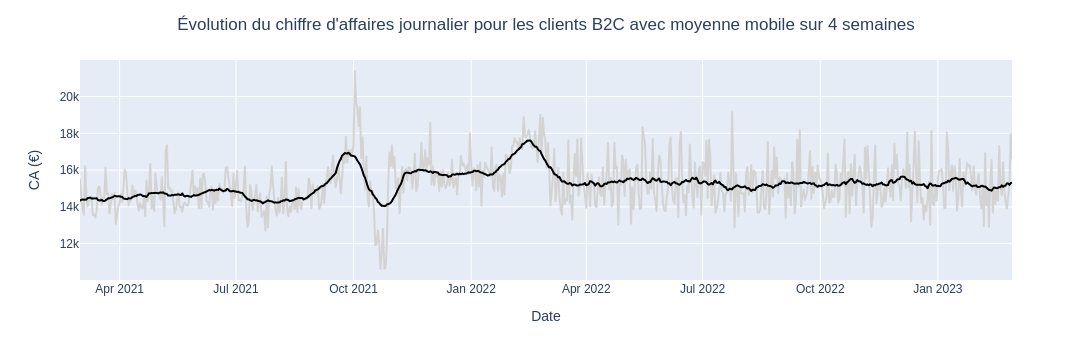

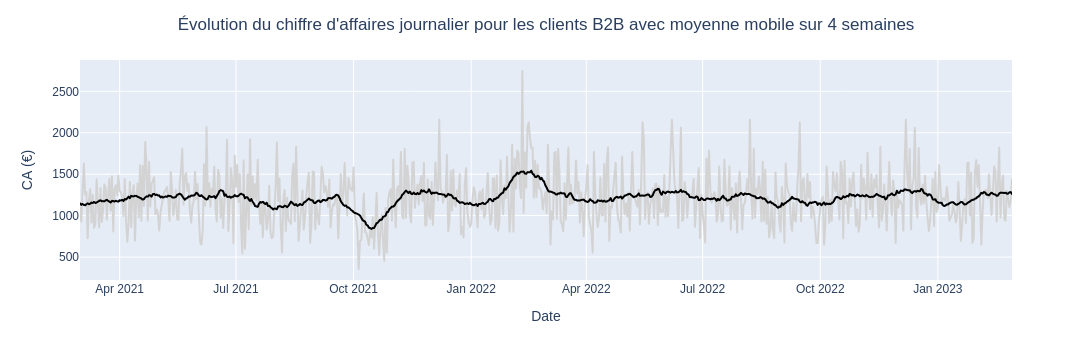

In [8]:
n_weeks = 4
for client_type, df in [ ("B2C", df_merge_b2c), ("B2B", df_merge_b2b) ]:
    df = df.groupby(pd.Grouper(key="date", freq="1d"))[["price"]].sum()
    df.rename(columns={"price":"total_amount_spent"}, inplace=True)
    df["total_amount_spent rolling mean"] = df["total_amount_spent"].rolling(window=f"{7*n_weeks}d", center=True).mean()
    df.reset_index(inplace=True)
    fig = px.line(
        df, x="date", y=["total_amount_spent","total_amount_spent rolling mean"], color_discrete_sequence=["lightgray","black"],
        labels={"date":"Date","total_amount_spent":"CA hebdomadaire","total_amount_spent rolling mean":f"Moyenne mobile sur {n_weeks} semaines"},
    )
    fig.update_layout(
        showlegend=False, # @bug px.line() with multiple y
        yaxis_title="CA (€)",
        title=f"Évolution du chiffre d'affaires journalier pour les clients {client_type} avec moyenne mobile sur {n_weeks} semaines",
        title_x=0.5,
    )
    fig.show()

## Évolution du chiffre d'affaires par catégorie

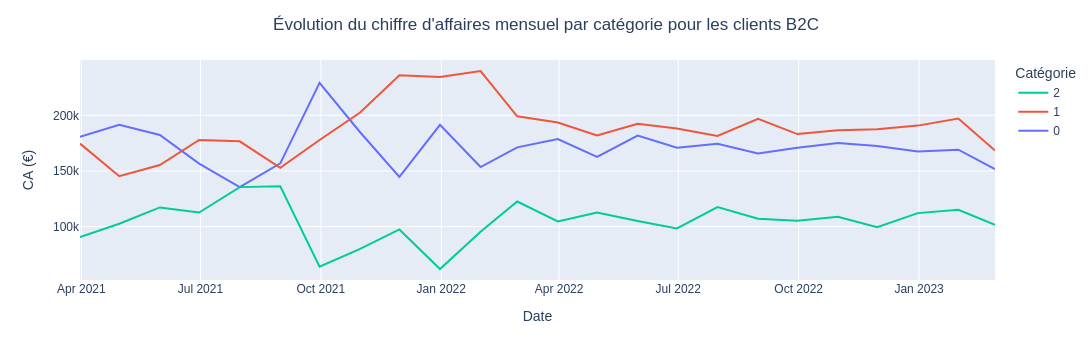

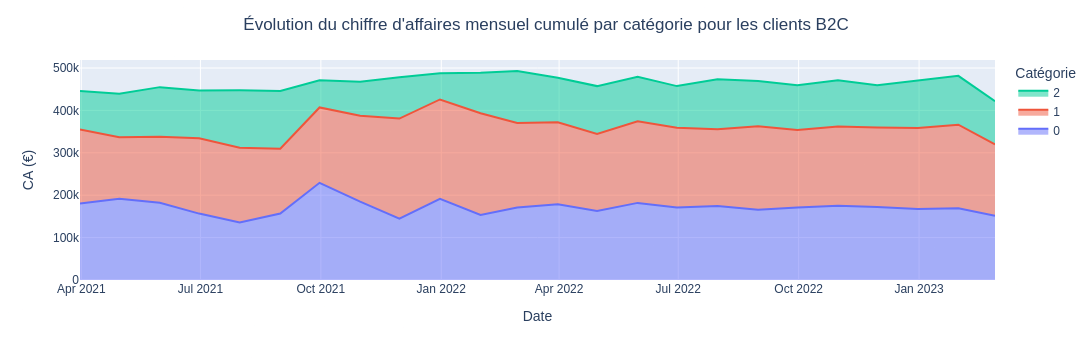

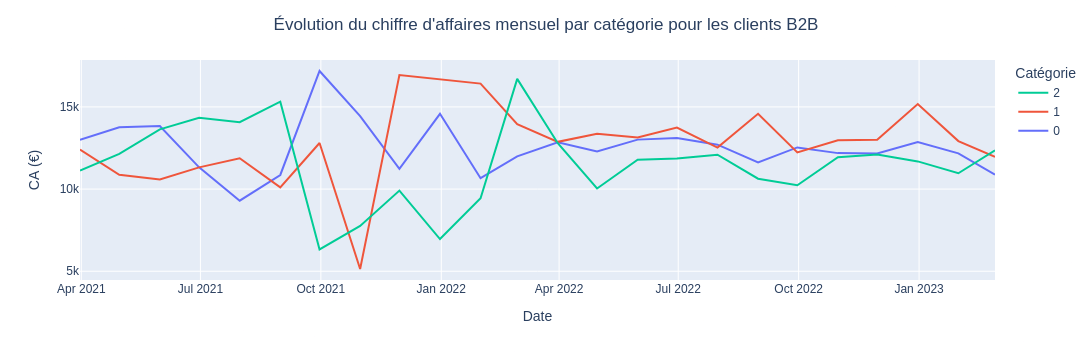

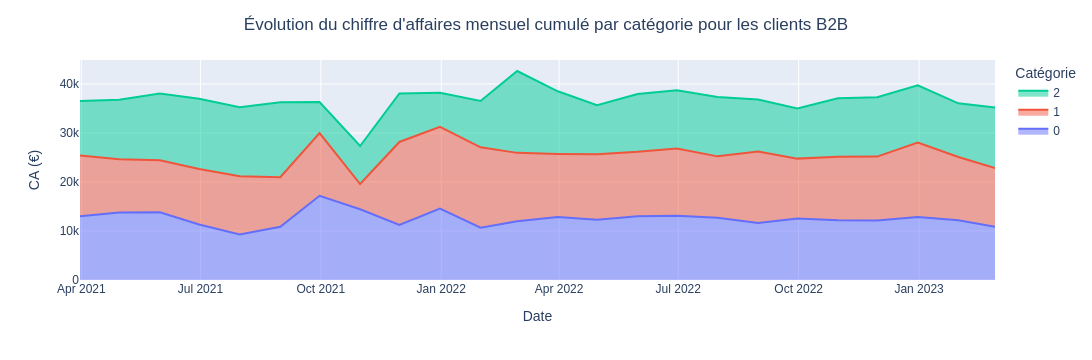

In [9]:
for client_type, df in [ ("B2C", df_merge_b2c), ("B2B", df_merge_b2b) ]:
    df = df.groupby(["categ",pd.Grouper(key="date", freq="1ME")])[["price"]].sum().reset_index()
    df.rename(columns={"price":"total_amount_spent"}, inplace=True)
    for px_plot_fn, cumulated in [ (px.line, False), (px.area, True) ]:
        fig = px_plot_fn(
            df, x="date", y="total_amount_spent", color="categ",
            labels={"date":"Date","total_amount_spent":"CA (€)","categ":"Catégorie"},
        )
        fig.update_layout(
            title=f"Évolution du chiffre d'affaires mensuel{' cumulé' * cumulated} par catégorie pour les clients {client_type}",
            title_x=0.5,
            legend_traceorder="reversed",
        )
        fig.show()

## Évolution du nombre de clients

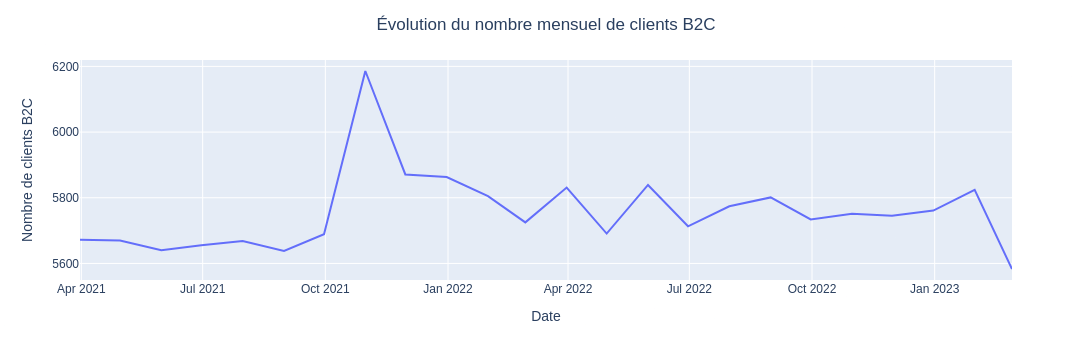

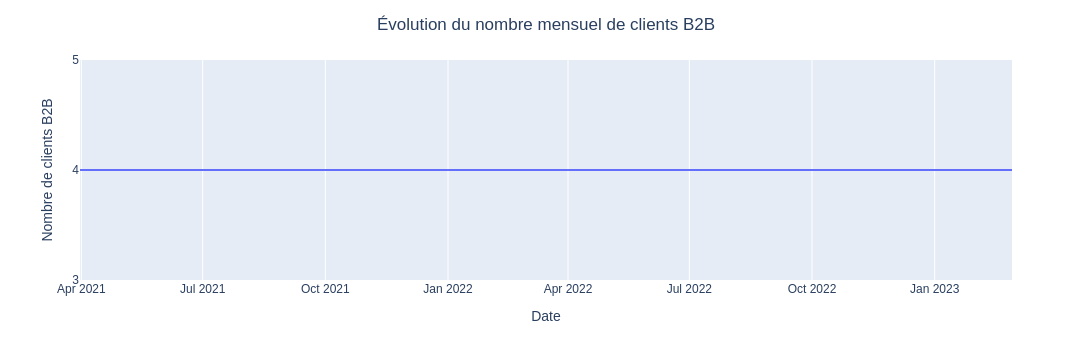

In [10]:
for client_type, df in [ ("B2C", df_merge_b2c), ("B2B", df_merge_b2b) ]:
    df = df.groupby(pd.Grouper(key="date", freq="1ME"))[["client_id"]].nunique().reset_index()
    df.rename(columns={"client_id":"nb_clients"}, inplace=True)
    fig = px.line(
        df, x="date", y="nb_clients",
        labels={"date":"Date","nb_clients":f"Nombre de clients {client_type}"},
    )
    if client_type == "B2B":
        fig.update_layout(yaxis_dtick=1)
    fig.update_layout(
        title=f"Évolution du nombre mensuel de clients {client_type}",
        title_x=0.5,
    )
    fig.show()

## Évolution du nombre de transactions

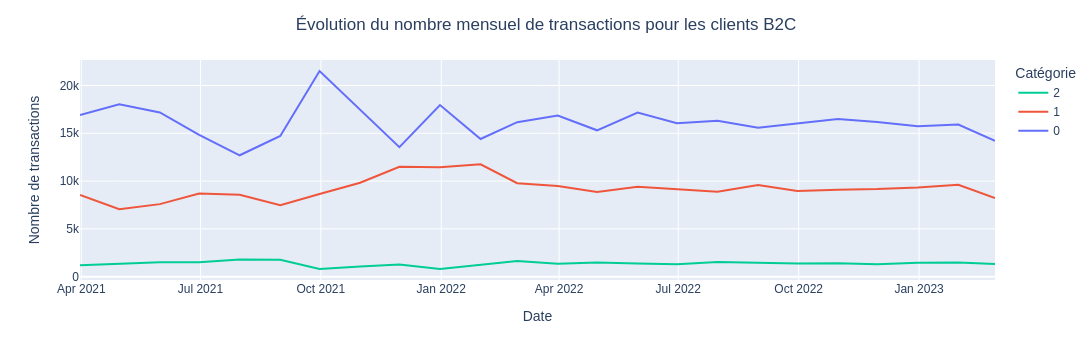

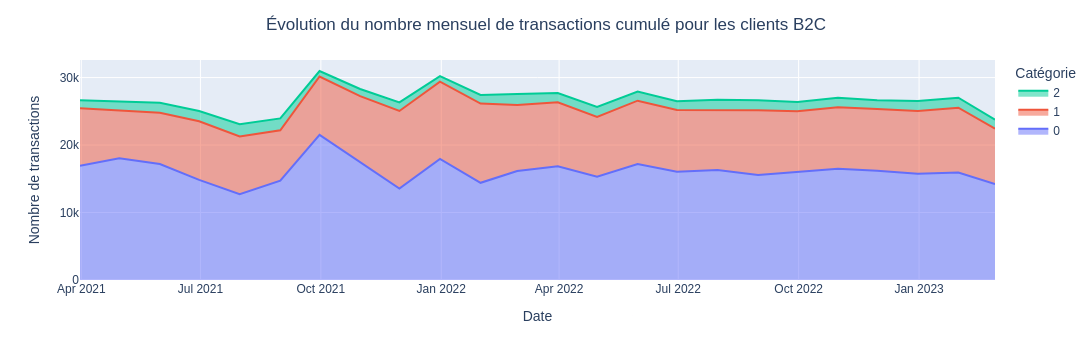

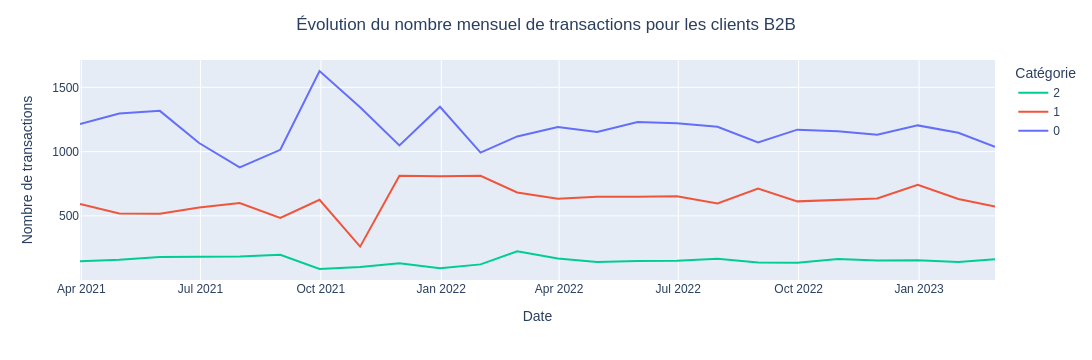

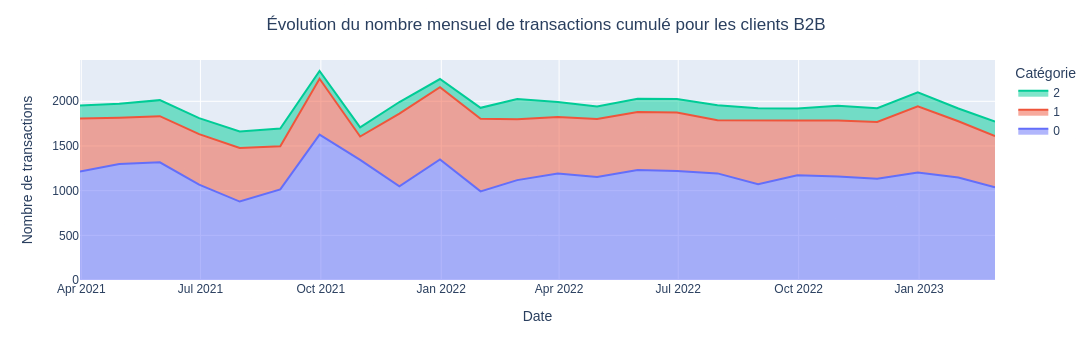

In [11]:
for client_type, df in [ ("B2C", df_merge_b2c), ("B2B", df_merge_b2b) ]:
    df = df.groupby(["categ",pd.Grouper(key="date", freq="1ME")])[["client_id"]].count().reset_index()
    df.rename(columns={"client_id":"nb_transactions"}, inplace=True)
    for px_plot_fn, cumulated in [ (px.line, False), (px.area, True) ]:
        fig = px_plot_fn(
            df, x="date", y="nb_transactions", color="categ",
            labels={"date":"Date","nb_transactions":"Nombre de transactions","categ":"Catégorie"},
        )
        fig.update_layout(
            title=f"Évolution du nombre mensuel de transactions{' cumulé' * cumulated} pour les clients {client_type}",
            title_x=0.5,
            legend_traceorder="reversed",
        )
        fig.show()

## Évolution du nombre de produits vendus

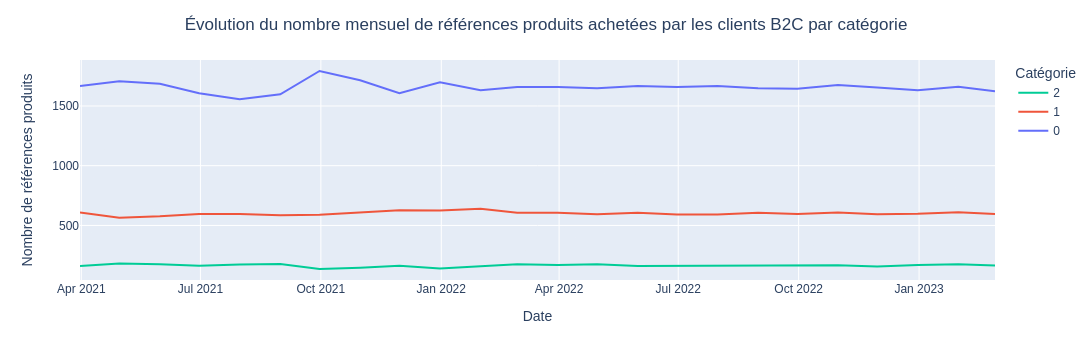

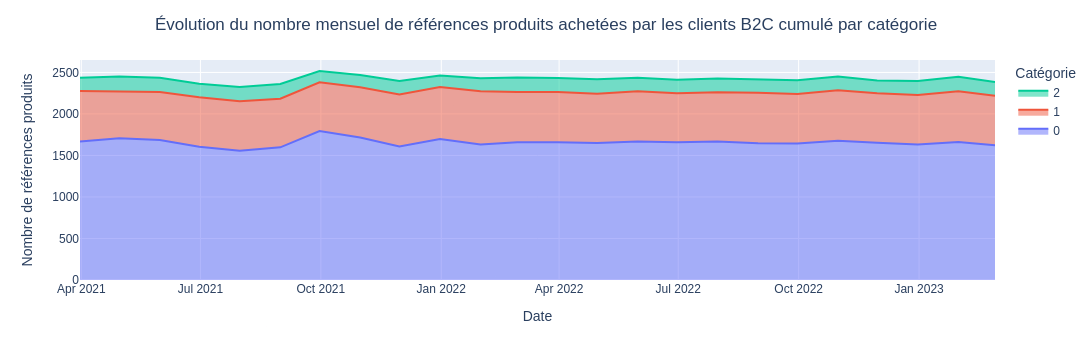

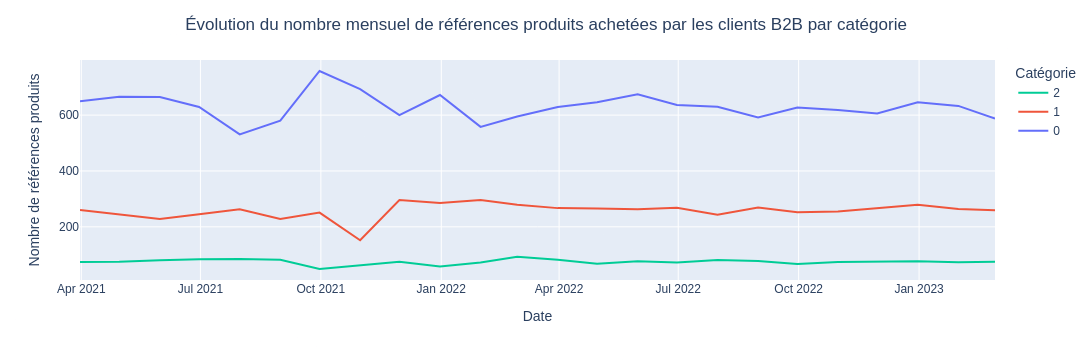

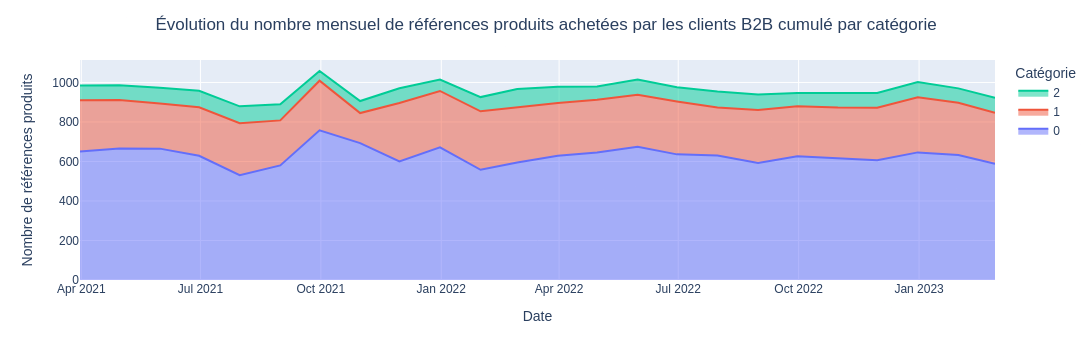

In [12]:
for client_type, df in [ ("B2C", df_merge_b2c), ("B2B", df_merge_b2b) ]:
    df = df.groupby(["categ",pd.Grouper(key="date", freq="1ME")])[["id_prod"]].nunique().reset_index()
    df.rename(columns={"id_prod":"nb_products"}, inplace=True)
    for px_plot_fn, cumulated in [ (px.line, False), (px.area, True) ]:
        fig = px_plot_fn(
            df, x="date", y="nb_products", color="categ",
            labels={"date":"Date","nb_products":"Nombre de références produits","categ":"Catégorie"},
        )
        fig.update_layout(
            title=f"Évolution du nombre mensuel de références produits achetées par les clients {client_type}{' cumulé' * cumulated} par catégorie",
            title_x=0.5,
            legend_traceorder="reversed",
        )
        fig.show()

# Zoom sur les références

## Répartition des produits par catégorie

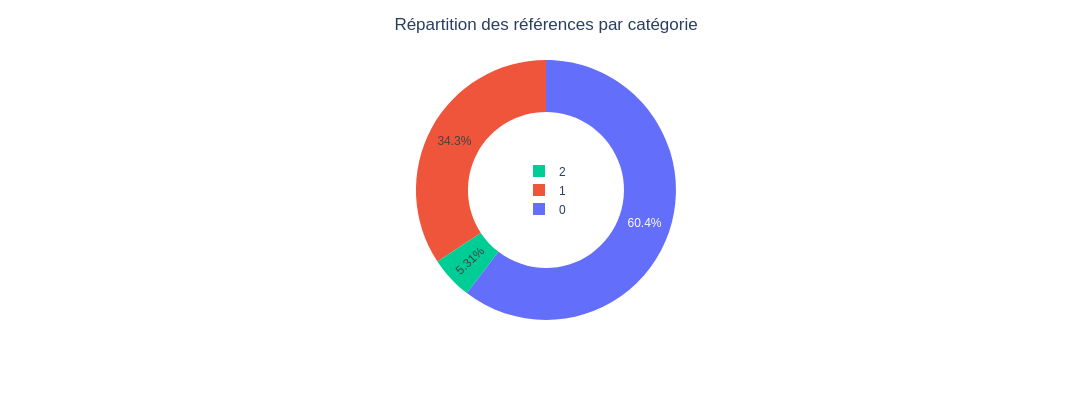

In [13]:
fig = px.pie(
    df_merge["categ"].value_counts().reset_index(),
    names="categ", values="count", labels={"categ":"Catégorie","count":"Nombre de références"},
    hole=0.6, width=600, height=400,
)
fig.update_traces(sort=False)
fig.update_layout(title="Répartition des références par catégorie", title_x=0.5)
fig.update_layout(legend=dict(x=0.5, y=0.5, xanchor="center", yanchor="middle", traceorder="reversed"))
fig.show()

## Agrégation des données par référence pour chaque type de client

In [14]:
df_products_b2c = df_merge_b2c.groupby(["id_prod","categ","price"]).aggregate({"price":["count","sum"]}).reset_index()
df_products_b2c.columns = [ "id_prod", "categ", "price", "nb_transactions", "total_amount_spent" ]
df_products_b2c

,id_prod,categ,price,nb_transactions,total_amount_spent
0,0_0,0,3.75,1147,4301.25
1,0_1,0,10.99,467,5132.33
2,0_10,0,17.95,20,359.00
3,0_100,0,20.60,3,61.80
4,0_1000,0,6.84,398,2722.32
...,...,...,...,...,...
3257,2_95,2,98.99,4,395.96
3258,2_96,2,47.91,553,26494.23
3259,2_97,2,160.99,11,1770.89
3260,2_98,2,149.74,1,149.74


In [15]:
df_products_b2b = df_merge_b2b.groupby(["id_prod","categ","price"]).aggregate({"price":["count","sum"]}).reset_index()
df_products_b2b.columns = [ "id_prod", "categ", "price", "nb_transactions", "total_amount_spent" ]
df_products_b2b

,id_prod,categ,price,nb_transactions,total_amount_spent
0,0_0,0,3.75,95,356.25
1,0_1,0,10.99,20,219.80
2,0_10,0,17.95,2,35.90
3,0_1000,0,6.84,34,232.56
4,0_1001,0,4.99,21,104.79
...,...,...,...,...,...
2350,2_9,2,54.99,33,1814.67
2351,2_91,2,96.99,3,290.97
2352,2_94,2,145.45,1,145.45
2353,2_96,2,47.91,45,2155.95


## Analyse du chiffre d'affaires

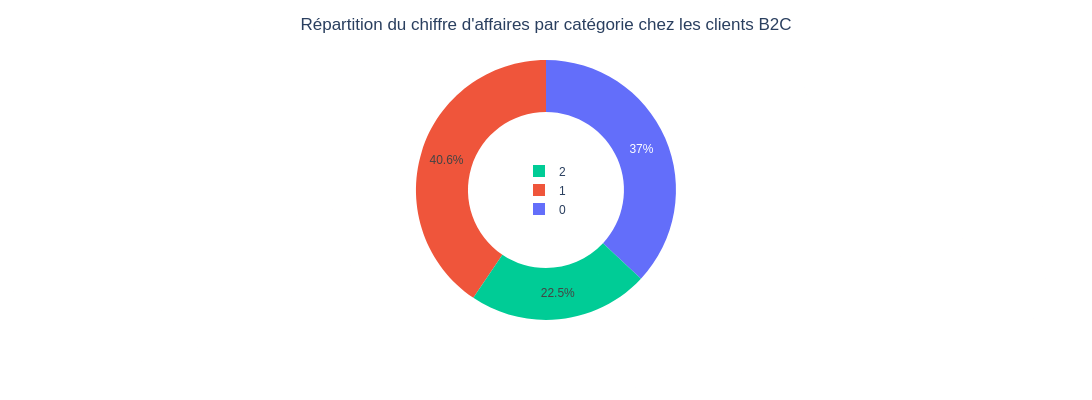

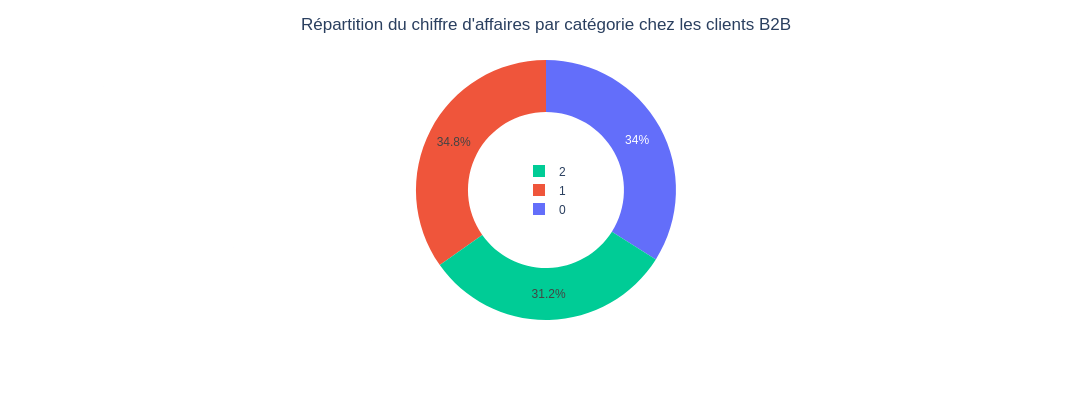

In [16]:
for client_type, df in [ ("B2C", df_products_b2c), ("B2B", df_products_b2b) ]:
    df = df.groupby("categ").sum().reset_index()
    
    fig = px.pie(
        df, names="categ", values="total_amount_spent", labels={"categ":"Catégorie","total_amount_spent":"CA (€)"},
        hole=0.6, width=600, height=400,
    )
    fig.update_traces(sort=False)
    fig.update_layout(title=f"Répartition du chiffre d'affaires par catégorie chez les clients {client_type}", title_x=0.5)
    fig.update_layout(legend=dict(x=0.5, y=0.5, xanchor="center", yanchor="middle", traceorder="reversed"))
    fig.show()

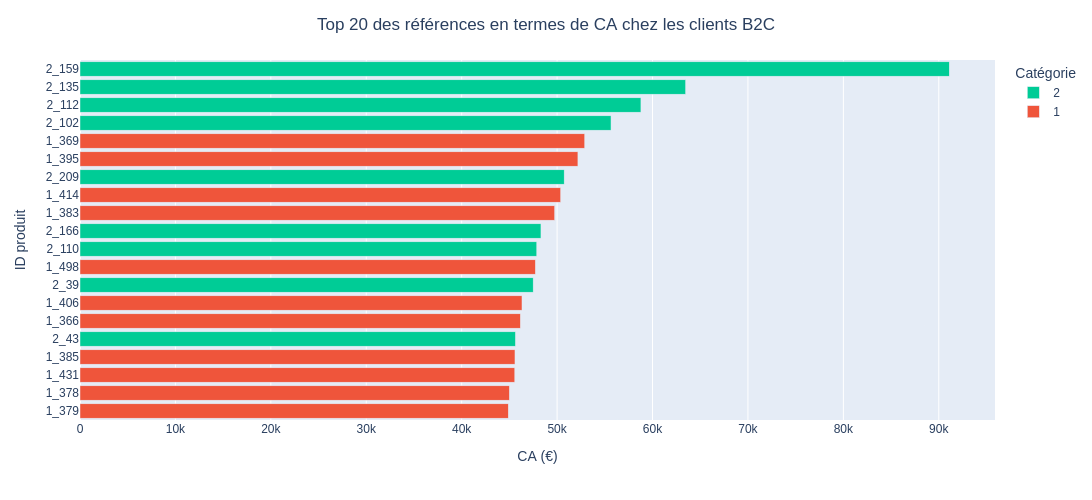

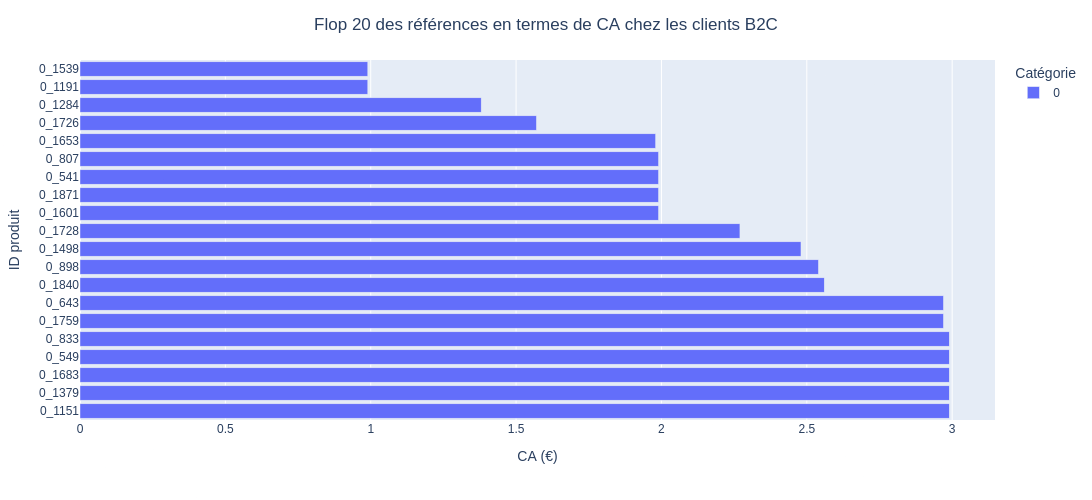

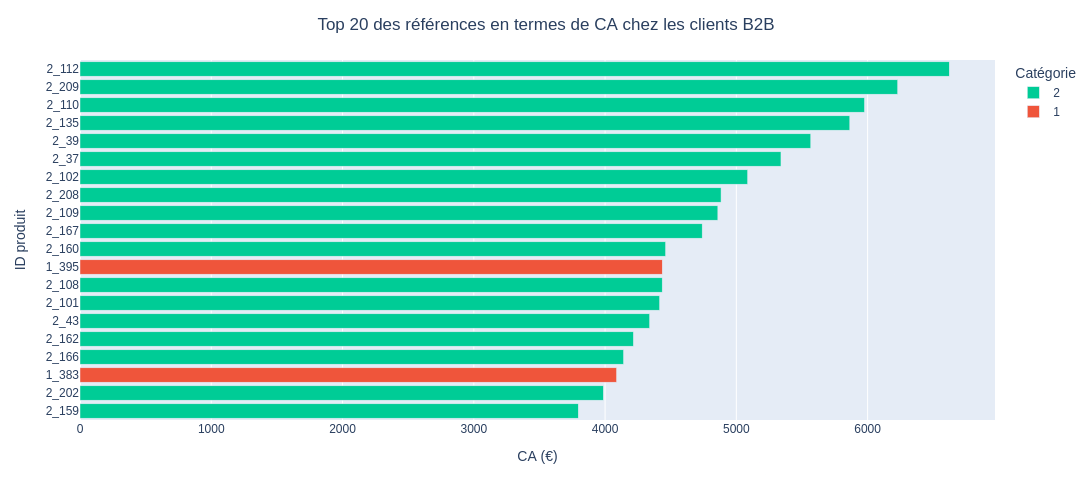

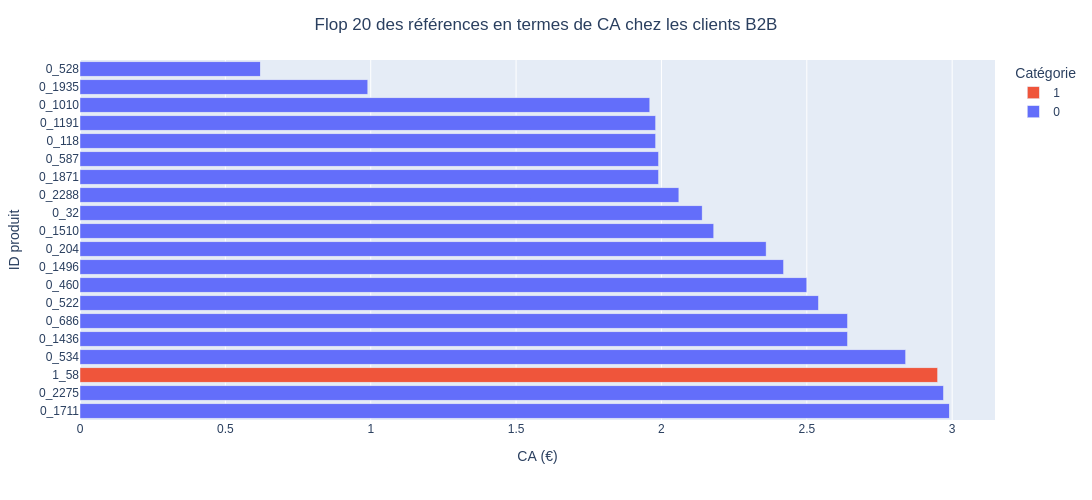

In [17]:
n = 20
for client_type, df in [ ("B2C", df_products_b2c), ("B2B", df_products_b2b) ]:
    df = df.sort_values(["total_amount_spent","id_prod"])
    
    fig = px.bar(
        df.tail(n), y="id_prod", x="total_amount_spent", color="categ", category_orders={"categ":["0","1","2"]},
        hover_name="id_prod", hover_data={"id_prod":False,"categ":True,"price":":.2f","nb_transactions":True,"total_amount_spent":":.2f"},
        labels={"id_prod":"ID produit","categ":"Catégorie","price":"Prix (€)","nb_transactions":"Nombre de transactions","total_amount_spent":"CA (€)"},
    )
    fig.update_layout(title=f"Top {n} des références en termes de CA chez les clients {client_type}", title_x=0.5)
    fig.update_layout(yaxis_categoryorder="total ascending", legend_traceorder="reversed", width=1000, height=500)
    fig.show()
    
    fig = px.bar(
        df.head(n), y="id_prod", x="total_amount_spent", color="categ", category_orders={"categ":["0","1","2"]},
        hover_name="id_prod", hover_data={"id_prod":False,"categ":True,"price":":.2f","nb_transactions":True,"total_amount_spent":":.2f"},
        labels={"id_prod":"ID produit","categ":"Catégorie","price":"Prix (€)","nb_transactions":"Nombre de transactions","total_amount_spent":"CA (€)"},
    )
    fig.update_layout(title=f"Flop {n} des références en termes de CA chez les clients {client_type}", title_x=0.5)
    fig.update_layout(yaxis_categoryorder="total descending", legend_traceorder="reversed", width=1000, height=500)
    fig.show()

## Analyse du nombre de transactions

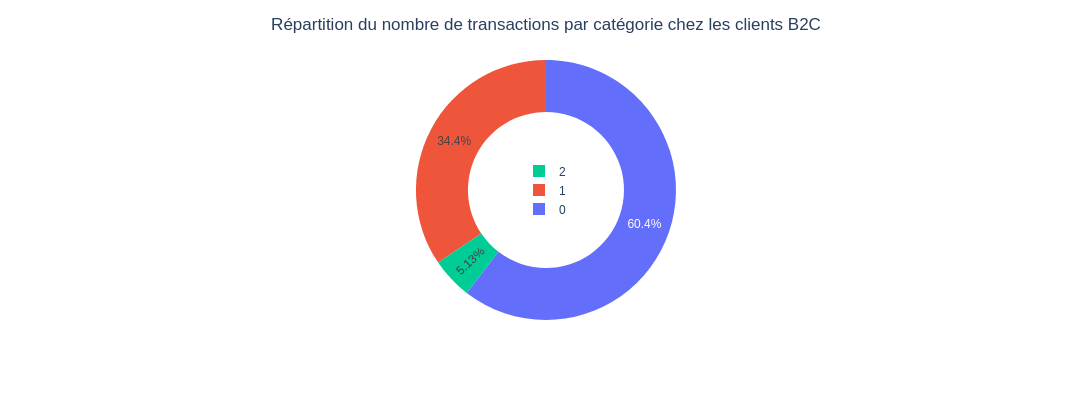

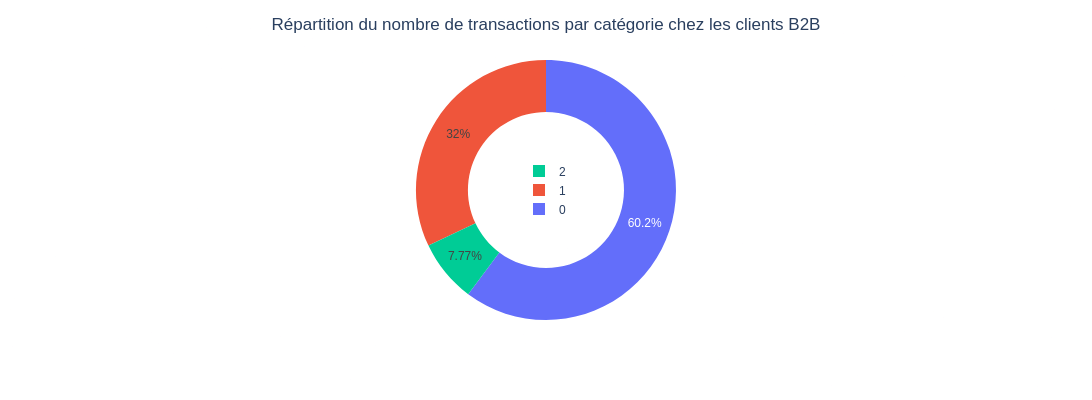

In [18]:
for client_type, df in [ ("B2C", df_products_b2c), ("B2B", df_products_b2b) ]:
    df = df.groupby("categ").sum().reset_index()
    
    fig = px.pie(
        df, names="categ", values="nb_transactions", labels={"categ":"Catégorie","nb_transactions":"Nombre de transactions"},
        hole=0.6, width=600, height=400,
    )
    fig.update_traces(sort=False)
    fig.update_layout(title=f"Répartition du nombre de transactions par catégorie chez les clients {client_type}", title_x=0.5)
    fig.update_layout(legend=dict(x=0.5, y=0.5, xanchor="center", yanchor="middle", traceorder="reversed"))
    fig.show()

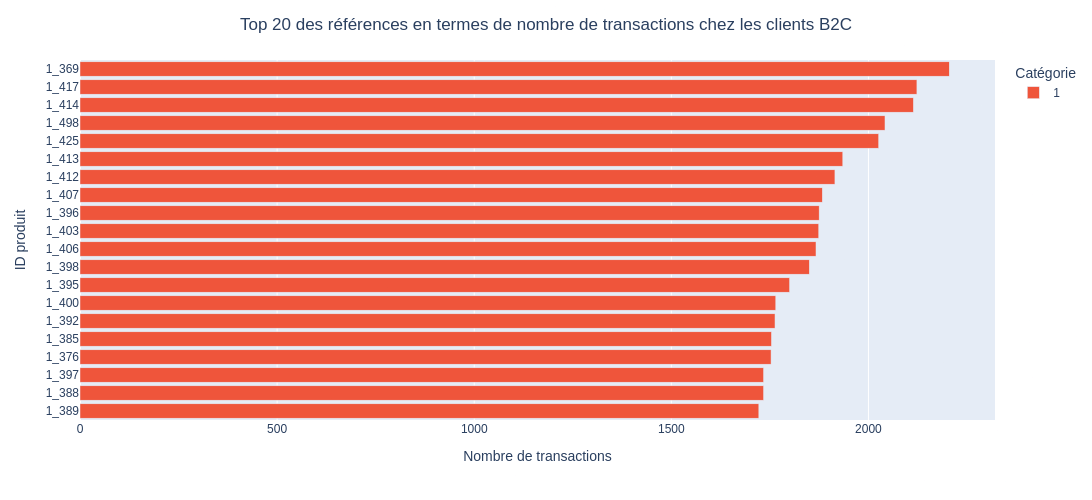

Références vendues une seule fois chez les clients B2C
     id_prod categ   price  nb_transactions  total_amount_spent
165   0_1151     0    2.99                1                2.99
209   0_1191     0    0.99                1                0.99
312   0_1284     0    1.38                1                1.38
416   0_1379     0    2.99                1                2.99
548   0_1498     0    2.48                1                2.48
588   0_1533     0   27.99                1               27.99
594   0_1539     0    0.99                1                0.99
664   0_1601     0    1.99                1                1.99
697   0_1633     0   24.99                1               24.99
751   0_1683     0    2.99                1                2.99
799   0_1726     0    1.57                1                1.57
801   0_1728     0    2.27                1                2.27
902   0_1820     0   22.30                1               22.30
958   0_1871     0    1.99                1      

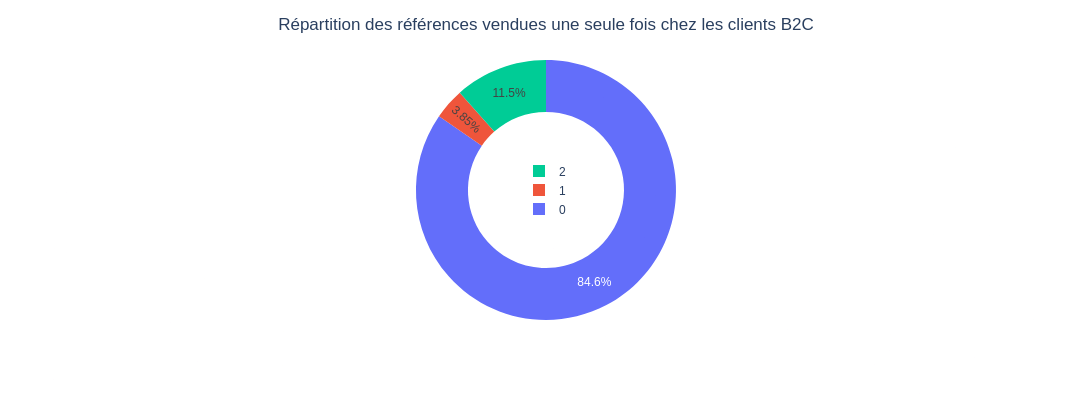

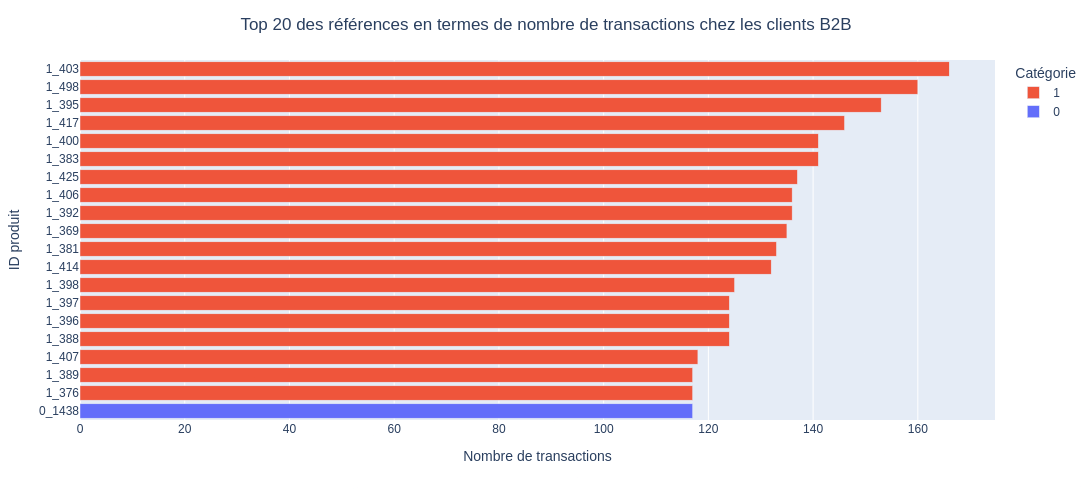

Références vendues une seule fois chez les clients B2B
     id_prod categ   price  nb_transactions  total_amount_spent
12    0_1010     0    1.96                1                1.96
62    0_1071     0   22.99                1               22.99
67    0_1076     0   25.11                1               25.11
80    0_1092     0   22.02                1               22.02
105   0_1122     0   20.02                1               20.02
...      ...   ...     ...              ...                 ...
2335    2_57     2  130.99                1              130.99
2341    2_64     2  163.94                1              163.94
2343    2_66     2  150.72                1              150.72
2348    2_88     2   77.63                1               77.63
2352    2_94     2  145.45                1              145.45

[205 rows x 5 columns]


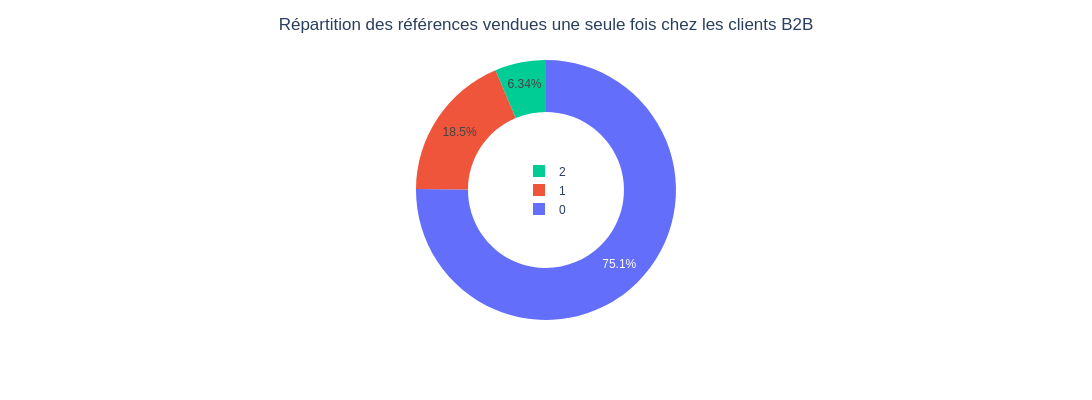

In [19]:
n = 20
for client_type, df in [ ("B2C", df_products_b2c), ("B2B", df_products_b2b) ]:
    df = df.sort_values(["nb_transactions","id_prod"])
    
    fig = px.bar(
        df.tail(n), y="id_prod", x="nb_transactions", color="categ", category_orders={"categ":["0","1","2"]},
        hover_name="id_prod", hover_data={"id_prod":False,"categ":True,"price":":.2f","nb_transactions":True,"total_amount_spent":":.2f"},
        labels={"id_prod":"ID produit","categ":"Catégorie","price":"Prix (€)","nb_transactions":"Nombre de transactions","total_amount_spent":"CA (€)"},
    )
    fig.update_layout(title=f"Top {n} des références en termes de nombre de transactions chez les clients {client_type}", title_x=0.5)
    fig.update_layout(yaxis_categoryorder="total ascending", legend_traceorder="reversed", width=1000, height=500)
    fig.show()

    df = df[ df["nb_transactions"] == 1 ]
    print(f"Références vendues une seule fois chez les clients {client_type}")
    print(df)

    fig = px.pie(
        df, names="categ", values="nb_transactions", category_orders={"categ":["0","1","2"]},
        labels={"categ":"Catégorie","nb_transactions":"Nombre de références vendues une seule fois"},
        hole=0.6, width=600, height=400,
    )
    fig.update_layout(title=f"Répartition des références vendues une seule fois chez les clients {client_type}", title_x=0.5)
    fig.update_layout(legend=dict(x=0.5, y=0.5, xanchor="center", yanchor="middle", traceorder="reversed"))
    fig.show()

# Analyse des profils clients

## Clients B2B

### Agrégation des données par client B2B avec le détail par catégorie

In [20]:
df_b2b_categ = df_merge_b2b.groupby(["client_id","categ"]).aggregate({ "price": [ "count", "sum" ] }).reset_index()
df_b2b_categ.columns = [ "client_id", "categ", "nb_transactions", "total_amount_spent" ]
df_b2b_categ

,client_id,categ,nb_transactions,total_amount_spent
0,c_1609,0,20167,214447.24
1,c_1609,1,5408,110091.44
2,c_1609,2,11,1501.21
3,c_3454,0,2697,28779.69
4,c_3454,1,4078,84055.66
5,c_3454,2,18,1275.22
6,c_4958,0,4,48.76
7,c_4958,1,1915,39841.93
8,c_4958,2,3303,250336.34
9,c_6714,0,5310,57254.59


### Analyse du chiffre d'affaires par client B2B

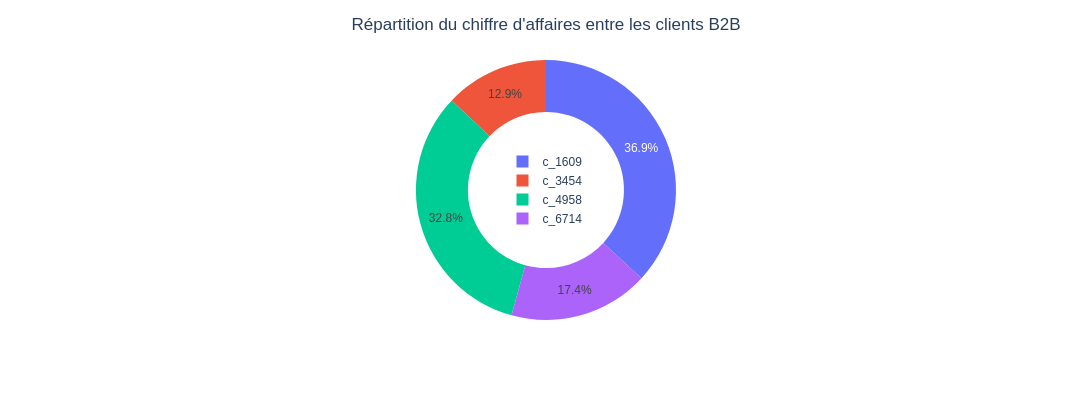

In [21]:
fig = px.pie(
    df_b2b_categ, names="client_id", values="total_amount_spent",
    labels={"client_id":"ID client","total_amount_spent":"CA (€)"},
    hole=0.6, width=600, height=400,
)
fig.update_traces(sort=False)
fig.update_layout(title="Répartition du chiffre d'affaires entre les clients B2B", title_x=0.5)
fig.update_layout(legend=dict(x=0.5, y=0.5, xanchor="center", yanchor="middle"))
fig.show()

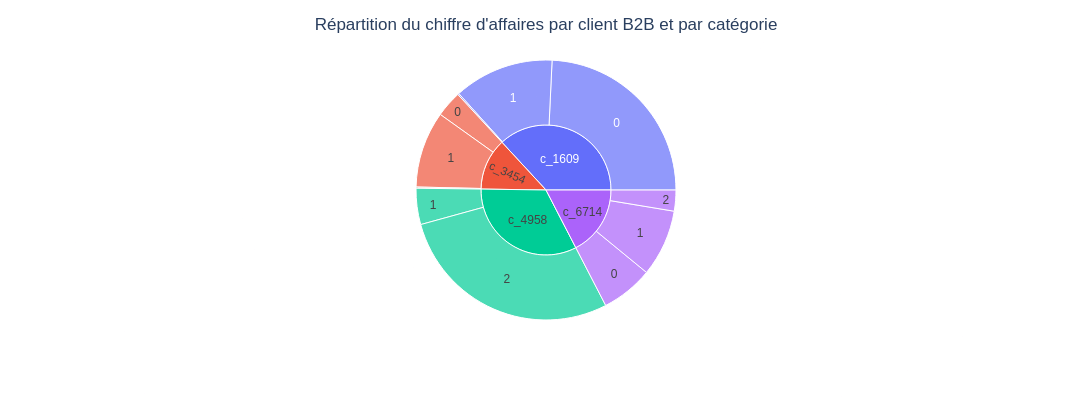

In [22]:
fig = px.sunburst(
    df_b2b_categ, path=["client_id","categ"], values="total_amount_spent",
    labels={"client_id":"ID client","categ":"Catégorie","total_amount_spent":"CA (€)"},
    width=600, height=400,
)
fig.update_traces(sort=False)
fig.update_layout(title="Répartition du chiffre d'affaires par client B2B et par catégorie", title_x=0.5)
fig.show()

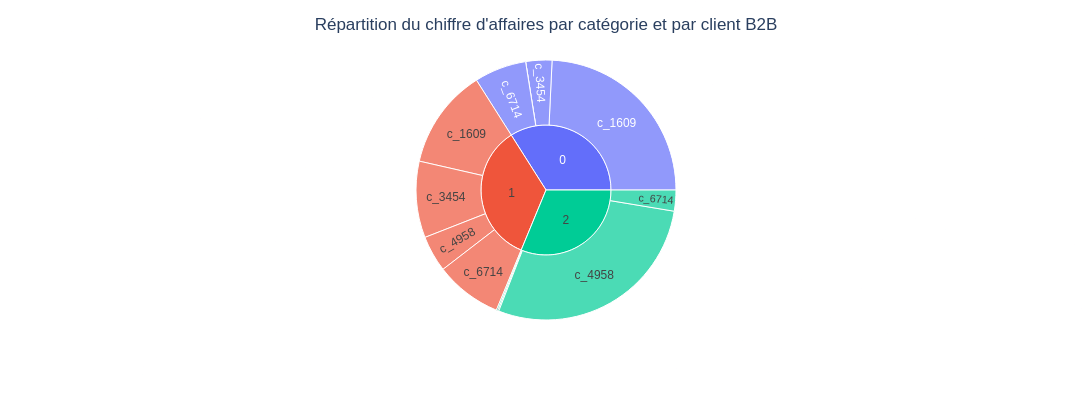

In [23]:
fig = px.sunburst(
    df_b2b_categ, path=["categ","client_id"], values="total_amount_spent",
    labels={"client_id":"ID client","categ":"Catégorie","total_amount_spent":"CA (€)"},
    width=600, height=400,
)
fig.update_traces(sort=False)
fig.update_layout(title="Répartition du chiffre d'affaires par catégorie et par client B2B", title_x=0.5)
fig.show()

### Analyse du nombre de transactions par client B2B

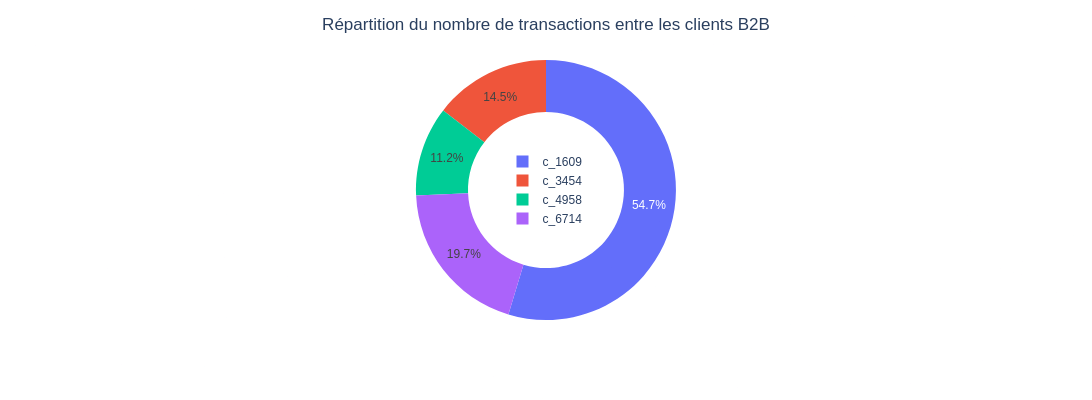

In [24]:
fig = px.pie(
    df_b2b_categ, names="client_id", values="nb_transactions",
    labels={"client_id":"ID client","nb_transactions":"Nombre de transactions"},
    hole=0.6, width=600, height=400,
)
fig.update_traces(sort=False)
fig.update_layout(title="Répartition du nombre de transactions entre les clients B2B", title_x=0.5)
fig.update_layout(legend=dict(x=0.5, y=0.5, xanchor="center", yanchor="middle"))
fig.show()

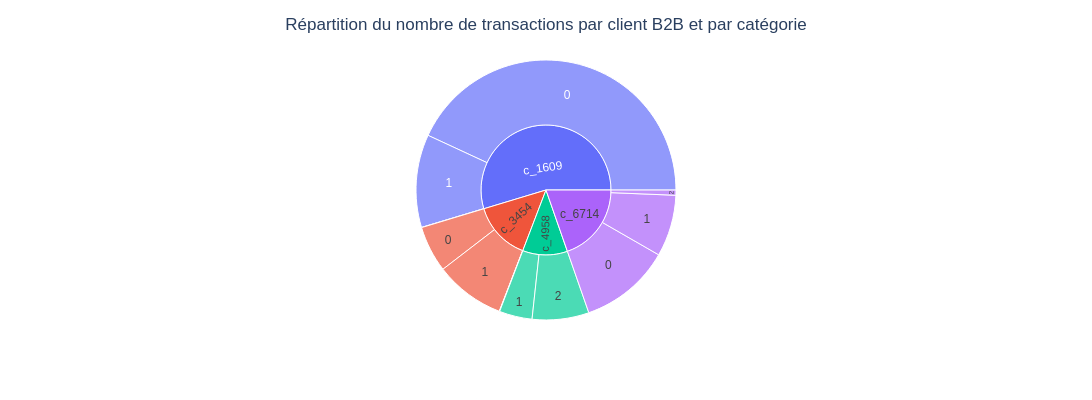

In [25]:
fig = px.sunburst(
    df_b2b_categ, path=["client_id","categ"], values="nb_transactions",
    labels={"client_id":"ID client","categ":"Catégorie","nb_transactions":"Nombre de transactions"},
    width=600, height=400,
)
fig.update_traces(sort=False)
fig.update_layout(title="Répartition du nombre de transactions par client B2B et par catégorie", title_x=0.5)
fig.show()

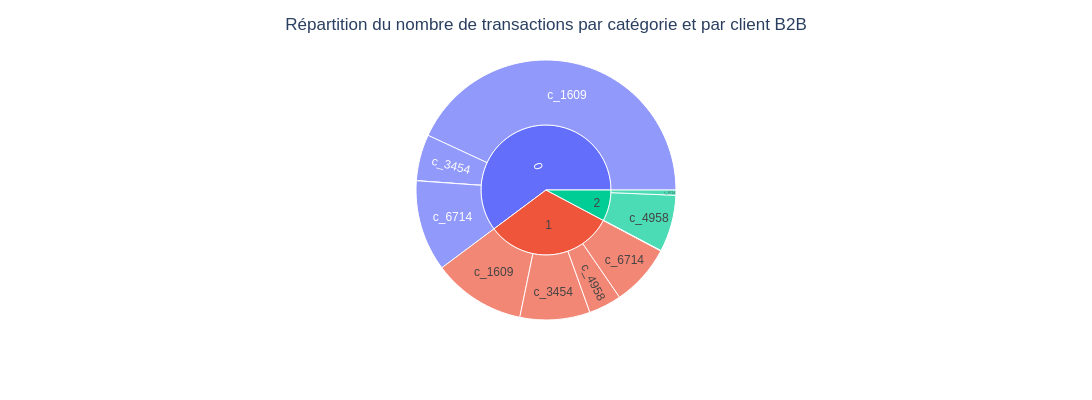

In [26]:
fig = px.sunburst(
    df_b2b_categ, path=["categ","client_id"], values="nb_transactions",
    labels={"client_id":"ID client","categ":"Catégorie","nb_transactions":"Nombre de transactions"},
    width=600, height=400,
)
fig.update_traces(sort=False)
fig.update_layout(title="Répartition du nombre de transactions par catégorie et par client B2B", title_x=0.5)
fig.show()

## Clients B2C

### Agrégation des données par client B2C

In [27]:
df_b2c = df_merge_b2c.groupby(["client_id"]).aggregate({ "price": [ "count", "sum" ] }).reset_index()
df_b2c.columns = [ "client_id", "nb_transactions", "total_amount_spent" ]
df_b2c

,client_id,nb_transactions,total_amount_spent
0,c_1,43,629.02
1,c_10,58,1353.60
2,c_100,8,254.85
3,c_1000,126,2291.88
4,c_1001,103,1823.85
...,...,...,...
8591,c_995,14,189.41
8592,c_996,96,1637.34
8593,c_997,59,1490.01
8594,c_998,55,2822.22


### Disparité des clients en termes de chiffre d'affaires

In [28]:
df_lorenz = pd.DataFrame()
df_lorenz["y"] = [ 0, *df_b2c["total_amount_spent"].sort_values() ]
df_lorenz["y"] = df_lorenz["y"] / df_lorenz["y"].sum()
df_lorenz["y"] = df_lorenz["y"].cumsum()
df_lorenz["x"] = np.linspace(0, 1, df_lorenz.shape[0])
df_lorenz = df_lorenz[["x","y"]] # Swap x and y
df_lorenz["line"] = "lorenz"
df_lorenz

,x,y,line
0,0.000000,0.000000e+00,lorenz
1,0.000116,5.662561e-07,lorenz
2,0.000233,1.311094e-06,lorenz
3,0.000349,2.206694e-06,lorenz
4,0.000465,3.211776e-06,lorenz
...,...,...,...
8592,0.999535,9.981122e-01,lorenz
8593,0.999651,9.985801e-01,lorenz
8594,0.999767,9.990521e-01,lorenz
8595,0.999884,9.995257e-01,lorenz


In [29]:
num = (df_lorenz["y"] > 0.20).sum()
den = df_lorenz["y"].shape[0] - 1
print(f"Part des clients générant 80% du CA : {num}/{den} = {100.*num/den:.2f}%")

Part des clients générant 80% du CA : 4500/8596 = 52.35%


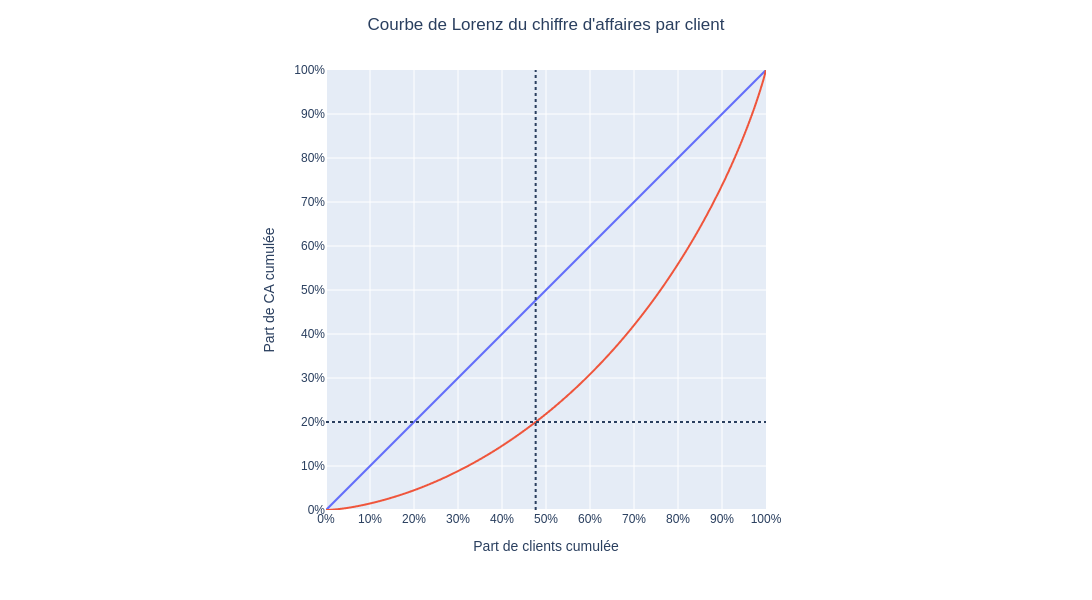

In [30]:
fig = px.line(
    pd.concat([ df_identity, df_lorenz ]), x="x", y="y", color="line",
    hover_data={"x":":.2%","y":":.2%","line":False},
    labels={"x":"Part de clients cumulée","y":"Part de CA cumulée"},
)
fig.add_hline(line_dash="dot", y=0.20)
fig.add_vline(line_dash="dot", x=(den-num)/den)
fig.update_layout(
    width=600, height=600, showlegend=False,
    xaxis={"range":(0,1),"dtick":0.10,"tickformat":".0%","constrain":"domain"},
    yaxis={"range":(0,1),"dtick":0.10,"tickformat":".0%","constrain":"domain","scaleanchor":"x","scaleratio":1},
    title="Courbe de Lorenz du chiffre d'affaires par client", title_x=0.5,
)
fig.show()

In [31]:
print(f"Indice de Gini = {indice_gini(df_b2c['total_amount_spent'].values):.3f}")

Indice de Gini = 0.398


### Disparité des clients en termes de nombre de transactions

In [32]:
df_lorenz = pd.DataFrame()
df_lorenz["y"] = [ 0, *df_b2c["nb_transactions"].sort_values() ]
df_lorenz["y"] = df_lorenz["y"] / df_lorenz["y"].sum()
df_lorenz["y"] = df_lorenz["y"].cumsum()
df_lorenz["x"] = np.linspace(0, 1, df_lorenz.shape[0])
df_lorenz = df_lorenz[["x","y"]] # Swap x and y
df_lorenz["line"] = "lorenz"
df_lorenz

,x,y,line
0,0.000000,0.000000,lorenz
1,0.000116,0.000002,lorenz
2,0.000233,0.000003,lorenz
3,0.000349,0.000005,lorenz
4,0.000465,0.000006,lorenz
...,...,...,...
8592,0.999535,0.997515,lorenz
8593,0.999651,0.998118,lorenz
8594,0.999767,0.998739,lorenz
8595,0.999884,0.999368,lorenz


In [33]:
num = (df_lorenz["y"] > 0.20).sum()
den = df_lorenz["y"].shape[0] - 1
print(f"Part des clients générant 80% du nombre de ventes : {num}/{den} = {100.*num/den:.2f}%")

Part des clients générant 80% du nombre de ventes : 4157/8596 = 48.36%


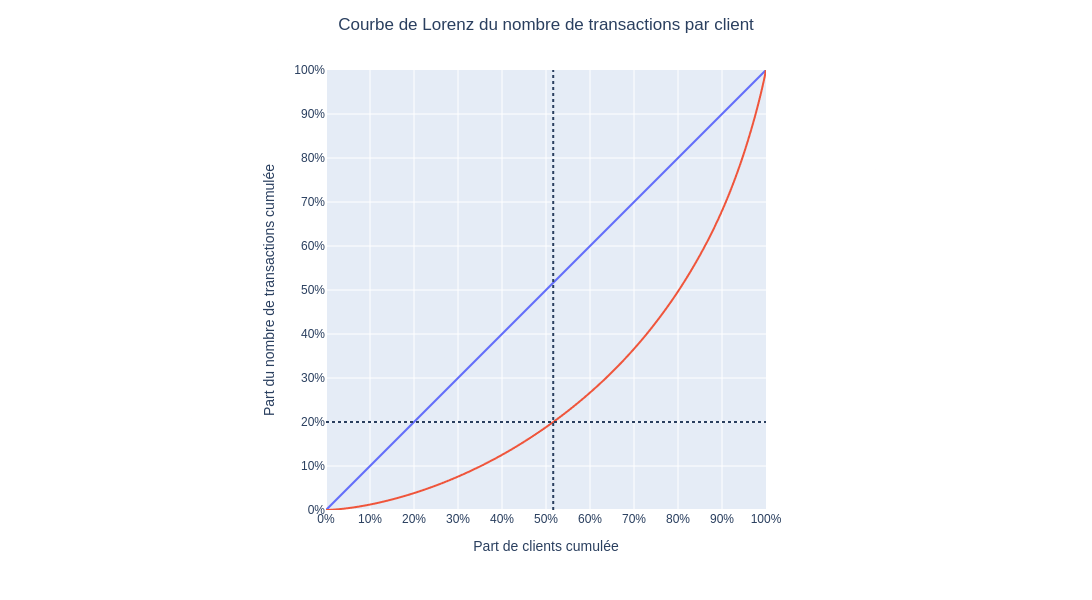

In [34]:
fig = px.line(
    pd.concat([ df_identity, df_lorenz ]), x="x", y="y", color="line",
    hover_data={"x":":.2%","y":":.2%","line":False},
    labels={"x":"Part de clients cumulée","y":"Part du nombre de transactions cumulée"},
)
fig.add_hline(line_dash="dot", y=0.20)
fig.add_vline(line_dash="dot", x=(den-num)/den)
fig.update_layout(
    width=600, height=600, showlegend=False,
    xaxis={"range":(0,1),"dtick":0.10,"tickformat":".0%","constrain":"domain"},
    yaxis={"range":(0,1),"dtick":0.10,"tickformat":".0%","constrain":"domain","scaleanchor":"x","scaleratio":1},
    title="Courbe de Lorenz du nombre de transactions par client", title_x=0.5,
)
fig.show()

In [35]:
print(f"Indice de Gini = {indice_gini(df_b2c['nb_transactions'].values):.3f}")

Indice de Gini = 0.458
